# Credit EDA Case Study

In [1]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss
%matplotlib inline

### Customize Global Behavior of DataFrame

In [12]:
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)

### Load and Inspect the Data

In [4]:
app_df = pd.read_csv("application_data.csv")

In [ ]:
app_df.head()

In [9]:
app_df.info(verbose=True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

In [ ]:
app_df['TARGET'].value_counts()

In [ ]:
app_df.TARGET.value_counts()

In [ ]:
24825/(282686+24825)*100

In [ ]:
app_df['NAME_CONTRACT_TYPE'].unique()

In [ ]:
app_df['NAME_CONTRACT_TYPE'].value_counts()

In [ ]:
prev_df = pd.read_csv('previous_application.csv')

In [ ]:
prev_df.head()

In [ ]:
prev_df.info()

In [ ]:
prev_df['NAME_CONTRACT_STATUS'].value_counts()

In [ ]:
prev_df.CODE_REJECT_REASON.unique()

In [ ]:
prev_df.CODE_REJECT_REASON.value_counts()

In [ ]:
df = pd.merge(app_df, prev_df, on='SK_ID_CURR', how='inner')

In [ ]:
df.head()

In [ ]:
df.info(verbose=True, show_counts = True)

### EDA on Application Data

In [5]:
app_df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

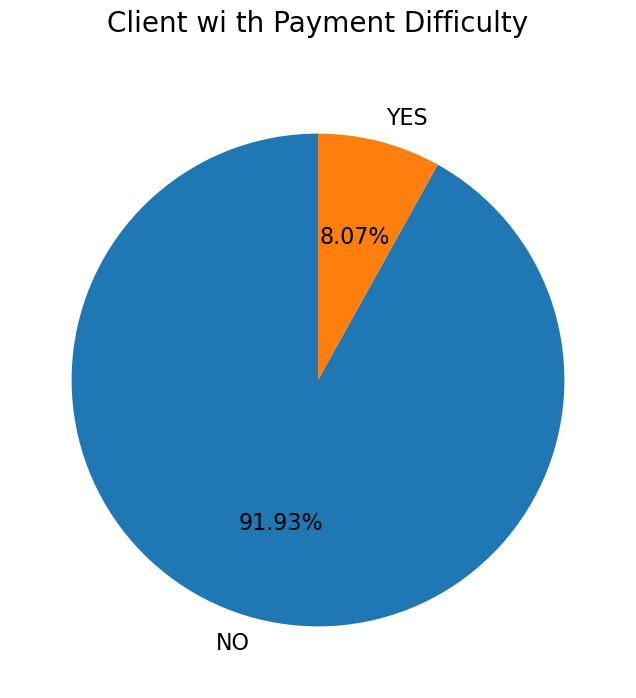

In [6]:
fig1 = plt.figure(figsize = [8,8])
y = [282686, 24825] 
mylabels = ["NO"  ,"YES"]
plt.pie(y, labels=mylabels, autopct='%1.2f%%', 
        textprops={'fontsize': 16, 'fontweight' : 20, 'color' : 'Black'}, startangle=90)
plt.title("Client wi th Payment Difficulty\n", fontdict={'fontsize': 20, 'fontweight' : 20, 'color' : 'Black'})
 
fig1.show()
# fig1.savefig('pie_plot_target.png', dpi=300, bbox_inches='tight')

In [7]:
app_df.CODE_GENDER.value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [8]:
app_non_missing = app_df.count()/len(app_df)
app_non_missing.head(20)

SK_ID_CURR                    1.000000
TARGET                        1.000000
NAME_CONTRACT_TYPE            1.000000
CODE_GENDER                   1.000000
FLAG_OWN_CAR                  1.000000
FLAG_OWN_REALTY               1.000000
CNT_CHILDREN                  1.000000
AMT_INCOME_TOTAL              1.000000
AMT_CREDIT                    1.000000
AMT_ANNUITY                   0.999961
AMT_GOODS_PRICE               0.999096
NAME_TYPE_SUITE               0.995799
NAME_INCOME_TYPE              1.000000
NAME_EDUCATION_TYPE           1.000000
NAME_FAMILY_STATUS            1.000000
NAME_HOUSING_TYPE             1.000000
REGION_POPULATION_RELATIVE    1.000000
DAYS_BIRTH                    1.000000
DAYS_EMPLOYED                 1.000000
DAYS_REGISTRATION             1.000000
dtype: float64

In [13]:
app_missing = (1-app_non_missing)*100
app_missing

SK_ID_CURR                       0.000000
TARGET                           0.000000
NAME_CONTRACT_TYPE               0.000000
CODE_GENDER                      0.000000
FLAG_OWN_CAR                     0.000000
FLAG_OWN_REALTY                  0.000000
CNT_CHILDREN                     0.000000
AMT_INCOME_TOTAL                 0.000000
AMT_CREDIT                       0.000000
AMT_ANNUITY                      0.003902
AMT_GOODS_PRICE                  0.090403
NAME_TYPE_SUITE                  0.420148
NAME_INCOME_TYPE                 0.000000
NAME_EDUCATION_TYPE              0.000000
NAME_FAMILY_STATUS               0.000000
NAME_HOUSING_TYPE                0.000000
REGION_POPULATION_RELATIVE       0.000000
DAYS_BIRTH                       0.000000
DAYS_EMPLOYED                    0.000000
DAYS_REGISTRATION                0.000000
DAYS_ID_PUBLISH                  0.000000
OWN_CAR_AGE                     65.990810
FLAG_MOBIL                       0.000000
FLAG_EMP_PHONE                   0

In [14]:
# app_missing = (1-app_non_missing)*100
app_missing.sort_values(ascending=False)

COMMONAREA_MEDI                 69.872297
COMMONAREA_AVG                  69.872297
COMMONAREA_MODE                 69.872297
NONLIVINGAPARTMENTS_MODE        69.432963
NONLIVINGAPARTMENTS_AVG         69.432963
NONLIVINGAPARTMENTS_MEDI        69.432963
FONDKAPREMONT_MODE              68.386172
LIVINGAPARTMENTS_MODE           68.354953
LIVINGAPARTMENTS_AVG            68.354953
LIVINGAPARTMENTS_MEDI           68.354953
FLOORSMIN_AVG                   67.848630
FLOORSMIN_MODE                  67.848630
FLOORSMIN_MEDI                  67.848630
YEARS_BUILD_MEDI                66.497784
YEARS_BUILD_MODE                66.497784
YEARS_BUILD_AVG                 66.497784
OWN_CAR_AGE                     65.990810
LANDAREA_MEDI                   59.376738
LANDAREA_MODE                   59.376738
LANDAREA_AVG                    59.376738
BASEMENTAREA_MEDI               58.515956
BASEMENTAREA_AVG                58.515956
BASEMENTAREA_MODE               58.515956
EXT_SOURCE_1                    56

In [15]:
app_df = app_df.loc[:, app_missing<50]

In [59]:
app_missing<50

SK_ID_CURR                       True
TARGET                           True
NAME_CONTRACT_TYPE               True
CODE_GENDER                      True
FLAG_OWN_CAR                     True
FLAG_OWN_REALTY                  True
CNT_CHILDREN                     True
AMT_INCOME_TOTAL                 True
AMT_CREDIT                       True
AMT_ANNUITY                      True
AMT_GOODS_PRICE                  True
NAME_TYPE_SUITE                  True
NAME_INCOME_TYPE                 True
NAME_EDUCATION_TYPE              True
NAME_FAMILY_STATUS               True
NAME_HOUSING_TYPE                True
REGION_POPULATION_RELATIVE       True
DAYS_BIRTH                       True
DAYS_EMPLOYED                    True
DAYS_REGISTRATION                True
DAYS_ID_PUBLISH                  True
OWN_CAR_AGE                     False
FLAG_MOBIL                       True
FLAG_EMP_PHONE                   True
FLAG_WORK_PHONE                  True
FLAG_CONT_MOBILE                 True
FLAG_PHONE  

In [16]:
app_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 81 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   SK_ID_CURR                    307511 non-null  int64  
 1   TARGET                        307511 non-null  int64  
 2   NAME_CONTRACT_TYPE            307511 non-null  object 
 3   CODE_GENDER                   307511 non-null  object 
 4   FLAG_OWN_CAR                  307511 non-null  object 
 5   FLAG_OWN_REALTY               307511 non-null  object 
 6   CNT_CHILDREN                  307511 non-null  int64  
 7   AMT_INCOME_TOTAL              307511 non-null  float64
 8   AMT_CREDIT                    307511 non-null  float64
 9   AMT_ANNUITY                   307499 non-null  float64
 10  AMT_GOODS_PRICE               307233 non-null  float64
 11  NAME_TYPE_SUITE               306219 non-null  object 
 12  NAME_INCOME_TYPE              307511 non-nul

In [17]:
app_df = app_df[app_df["CODE_GENDER"].str.contains("XNA") == False]

In [18]:
app_df.shape

(307507, 81)

In [19]:
app_df["CODE_GENDER"].value_counts()

CODE_GENDER
F    202448
M    105059
Name: count, dtype: int64

In [20]:
### frequency table using crosstab()function
 
my_crosstab = pd.crosstab(index=app_df["CODE_GENDER"], 
                            columns=app_df["TARGET"],
                             margins=True)   # Include row and column totals
my_crosstab

TARGET,0,1,All
CODE_GENDER,,,
F,188278,14170,202448
M,94404,10655,105059
All,282682,24825,307507


In [21]:
#### Rename the index and columns
 
my_crosstab.columns = ["No" , "Yes" , "rowtotal"]
my_crosstab.index= ["Female","Male","Total"]
my_crosstab

,No,Yes,rowtotal
Female,188278,14170,202448
Male,94404,10655,105059
Total,282682,24825,307507


In [22]:
#### Get the row proportion
 
gen_prop = round(my_crosstab.div(my_crosstab["rowtotal"],axis=0)*100,2)

In [ ]:
# gen_prop1 = round(my_crosstab.div(my_crosstab['Total'],axis=0)*100,2)

In [23]:
gen_prop

,No,Yes,rowtotal
Female,93.00,7.00,100.0
Male,89.86,10.14,100.0
Total,91.93,8.07,100.0


In [24]:
gen_prop.reset_index(level=0, inplace=True)

In [25]:
gen_prop

,index,No,Yes,rowtotal
0,Female,93.00,7.00,100.0
1,Male,89.86,10.14,100.0
2,Total,91.93,8.07,100.0


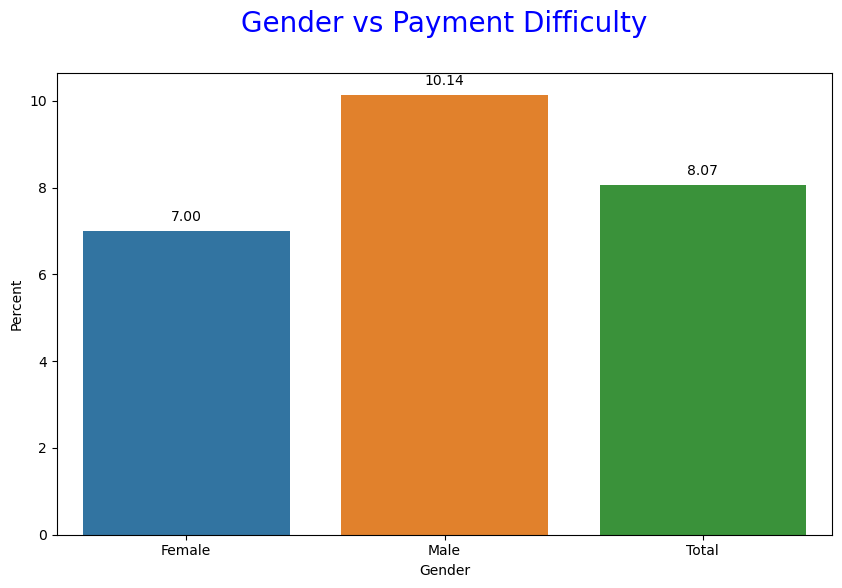

In [26]:
fig1 = plt.figure(figsize = [10,6])
ax = sns.barplot(x = 'index',
            y = 'Yes',
            data = gen_prop)
plt.xlabel("Gender")
plt.ylabel("Percent")
plt.title("Gender vs Payment Difficulty\n", fontdict={'fontsize': 20, 'fontweight' :205, 'color' : 'Blue'})
for p in ax.patches:
    ax.annotate(f'{p.get_height():0.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
fig1.show()
# fig1.savefig('bar_gen_tar.png', bbox_inches='tight')

In [27]:
app_df["CNT_CHILDREN"].value_counts()

CNT_CHILDREN
0     215369
1      61118
2      26748
3       3717
4        429
5         84
6         21
7          7
14         3
8          2
9          2
12         2
10         2
19         2
11         1
Name: count, dtype: int64

In [28]:
### frequency table using crosstab()function
 
my_crosstab = pd.crosstab(index=app_df["CNT_CHILDREN"], 
                            columns=app_df["TARGET"],
                             margins=True)   # Include row and column totals
my_crosstab

TARGET,0,1,All
CNT_CHILDREN,,,
0,198760,16609,215369
1,55664,5454,61118
2,24415,2333,26748
3,3359,358,3717
4,374,55,429
5,77,7,84
6,15,6,21
7,7,0,7
8,2,0,2


In [29]:
#### Rename the index and columns
 
my_crosstab.columns = ["No" , "Yes" , "rowtotal"]
my_crosstab.index= ["0","1","2", "3","4","5","6","7","8","9","10","11","12", "14","19", "Total"]
my_crosstab

,No,Yes,rowtotal
0,198760,16609,215369
1,55664,5454,61118
2,24415,2333,26748
3,3359,358,3717
4,374,55,429
5,77,7,84
6,15,6,21
7,7,0,7
8,2,0,2
9,0,2,2


In [30]:
### Get the row proportion
 
child_prop = round(my_crosstab.div(my_crosstab["rowtotal"],axis=0)*100,2)

In [ ]:
my_crosstab['rowtotal'].median()

In [ ]:
child_prop.iloc[[0,1,2,3,4,5,6]]

In [31]:
child_prop.reset_index(level=0, inplace=True)

In [32]:
child_prop

,index,No,Yes,rowtotal
0,0,92.29,7.71,100.0
1,1,91.08,8.92,100.0
2,2,91.28,8.72,100.0
3,3,90.37,9.63,100.0
4,4,87.18,12.82,100.0
5,5,91.67,8.33,100.0
6,6,71.43,28.57,100.0
7,7,100.00,0.00,100.0
8,8,100.00,0.00,100.0
9,9,0.00,100.00,100.0


In [ ]:
app_df.info()

<Axes: >

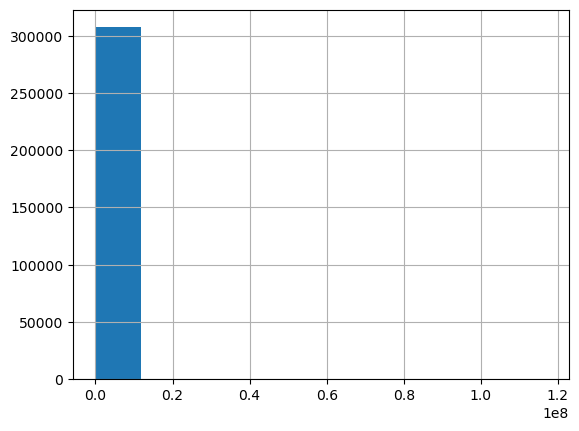

In [33]:
app_df["AMT_INCOME_TOTAL"].hist()

In [36]:
round(app_df["AMT_INCOME_TOTAL"].describe(percentiles = [.25,.5,.75,.85,.9,.95,.99]))

count       307507.0
mean        168798.0
std         237125.0
min          25650.0
25%         112500.0
50%         147150.0
75%         202500.0
85%         234000.0
90%         270000.0
95%         337500.0
99%         472500.0
max      117000000.0
Name: AMT_INCOME_TOTAL, dtype: float64

In [34]:
app_df["AMT_INCOME_TOTAL"].skew()

391.5574134299243

In [ ]:
(app_df["AMT_INCOME_TOTAL"] > 20000000).sum()

{'whiskers': [<matplotlib.lines.Line2D at 0x1db01693750>,
 'caps': [<matplotlib.lines.Line2D at 0x1db01980ed0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1db019728d0>],
 'medians': [<matplotlib.lines.Line2D at 0x1db01982590>],
 'fliers': [<matplotlib.lines.Line2D at 0x1db01722f90>],
 'means': []}

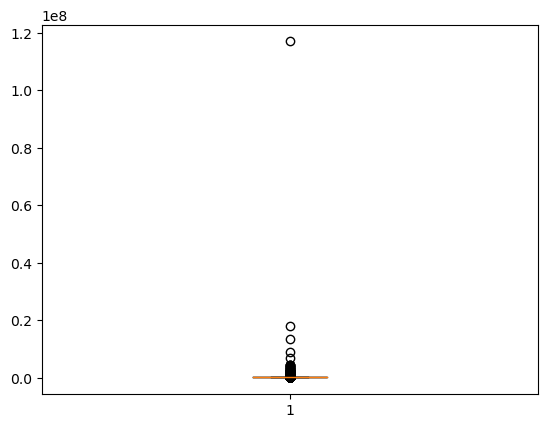

In [35]:
plt.boxplot(app_df["AMT_INCOME_TOTAL"])

In [ ]:
app_df["AMT_INCOME_TOTAL"].hist()

In [37]:
ucl = 202500 + 1.5*(202500 - 112500)
ucl

337500.0

In [38]:
(app_df.AMT_INCOME_TOTAL>337500).sum()

14035

In [39]:
app_df.AMT_INCOME_TOTAL[app_df.AMT_INCOME_TOTAL > 337500] = 337500

{'whiskers': [<matplotlib.lines.Line2D at 0x1db019e8990>,
 'caps': [<matplotlib.lines.Line2D at 0x1db019ea090>,
 'boxes': [<matplotlib.lines.Line2D at 0x1db019dfd50>],
 'medians': [<matplotlib.lines.Line2D at 0x1db019eb550>],
 'fliers': [<matplotlib.lines.Line2D at 0x1db019ebfd0>],
 'means': []}

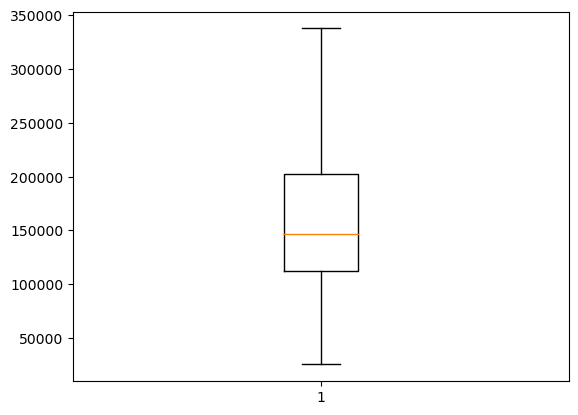

In [40]:
plt.boxplot(app_df["AMT_INCOME_TOTAL"])

<Axes: >

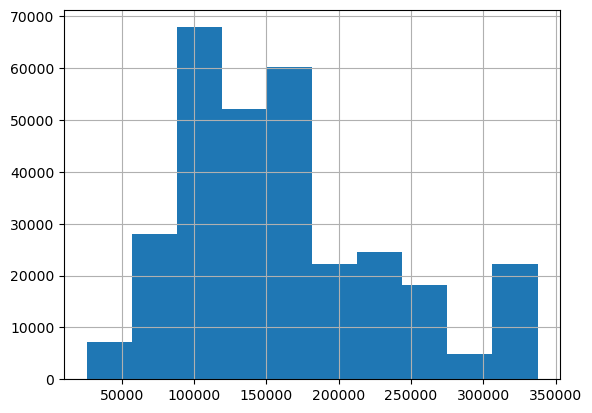

In [41]:
app_df["AMT_INCOME_TOTAL"].hist()

In [42]:
app_df["AMT_INCOME_TOTAL"].skew()

0.7836972234705927

In [ ]:
app_df.AMT_INCOME_TOTAL.hist()

In [43]:
app_df.AMT_INCOME_TOTAL.describe()

count    307507.000000
mean     162626.634089
std       73303.406713
min       25650.000000
25%      112500.000000
50%      147150.000000
75%      202500.000000
max      337500.000000
Name: AMT_INCOME_TOTAL, dtype: float64

In [44]:
app_df['Income_Class'] = pd.cut(app_df['AMT_INCOME_TOTAL'], [0,50000,100000,150000,200000,250000,300000,350000])

In [45]:
app_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,YEARS_BEGINEXPLUATATION_AVG,FLOORSMAX_AVG,YEARS_BEGINEXPLUATATION_MODE,FLOORSMAX_MODE,YEARS_BEGINEXPLUATATION_MEDI,FLOORSMAX_MEDI,TOTALAREA_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,Income_Class
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.262949,0.139376,0.9722,0.0833,0.9722,0.0833,0.9722,0.0833,0.0149,No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,"(200000, 250000]"
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.622246,NaN,0.9851,0.2917,0.9851,0.2917,0.9851,0.2917,0.0714,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,"(250000, 300000]"
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,"(50000, 100000]"
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,"(100000, 150000]"
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,1,1,0,1,0,0,Core staff,1.0,2,2,THURSDAY,11,0,0,0,0,1,1,Religion,0.322738,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-1106.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,"(100000, 150000]"


In [46]:
### frequency table using crosstab()function
 
my_crosstab = pd.crosstab(index=app_df["Income_Class"], 
                            columns=app_df["TARGET"],
                             margins=True)   # Include row and column totals
my_crosstab

TARGET,0,1,All
Income_Class,,,
"(0, 50000]",4174,343,4517
"(50000, 100000]",54299,4882,59181
"(100000, 150000]",83696,7894,91590
"(150000, 200000]",58874,5432,64306
"(200000, 250000]",44407,3728,48135
"(250000, 300000]",15846,1193,17039
"(300000, 350000]",21386,1353,22739
All,282682,24825,307507


In [47]:
#### Rename the index and columns
 
my_crosstab.columns = ["No" , "Yes" , "rowtotal"]
my_crosstab.index= ["< 50K", "50K-100K","100K-150K","150K-200K","200K-250K","250K-300K",">=300K","Total"]
my_crosstab

,No,Yes,rowtotal
< 50K,4174,343,4517
50K-100K,54299,4882,59181
100K-150K,83696,7894,91590
150K-200K,58874,5432,64306
200K-250K,44407,3728,48135
250K-300K,15846,1193,17039
>=300K,21386,1353,22739
Total,282682,24825,307507


In [48]:
### Get the row proportion
 
income_prop = round(my_crosstab.div(my_crosstab["rowtotal"],axis=0)*100,2)
income_prop


,No,Yes,rowtotal
< 50K,92.41,7.59,100.0
50K-100K,91.75,8.25,100.0
100K-150K,91.38,8.62,100.0
150K-200K,91.55,8.45,100.0
200K-250K,92.26,7.74,100.0
250K-300K,93.00,7.00,100.0
>=300K,94.05,5.95,100.0
Total,91.93,8.07,100.0


In [49]:
income_prop.reset_index(level=0, inplace=True)

In [50]:
income_prop

,index,No,Yes,rowtotal
0,< 50K,92.41,7.59,100.0
1,50K-100K,91.75,8.25,100.0
2,100K-150K,91.38,8.62,100.0
3,150K-200K,91.55,8.45,100.0
4,200K-250K,92.26,7.74,100.0
5,250K-300K,93.00,7.00,100.0
6,>=300K,94.05,5.95,100.0
7,Total,91.93,8.07,100.0


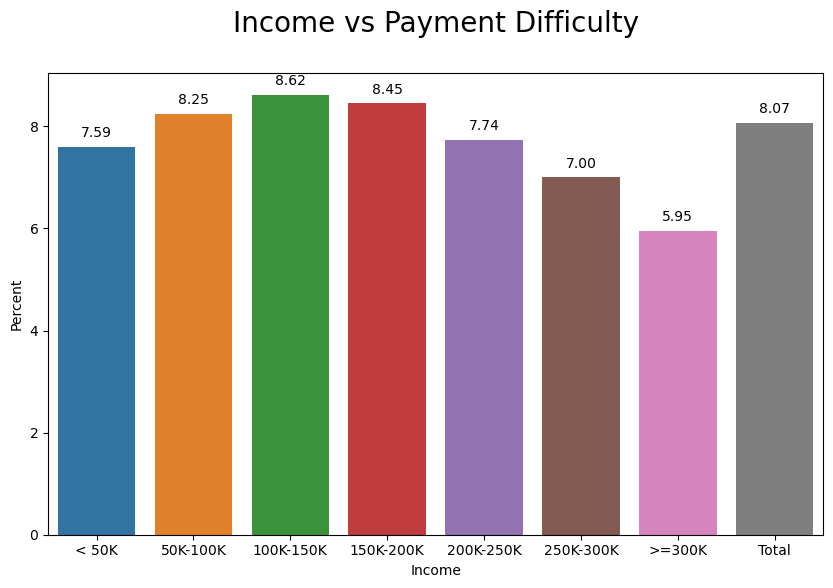

In [51]:
fig2 = plt.figure(figsize = [10,6])
ax = sns.barplot(x = 'index',
            y = 'Yes', 
            data = income_prop)
plt.xlabel("Income")
plt.ylabel("Percent")
plt.title("Income vs Payment Difficulty\n", fontdict={'fontsize': 20, 'fontweight' : 20, 'color' : 'Black'})
for p in ax.patches:
    ax.annotate(f'{p.get_height():0.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
fig2.show()
# fig2.savefig('bar_inc_tar.png', bbox_inches='tight')

In [52]:
app_df["FLAG_OWN_CAR"].value_counts()

FLAG_OWN_CAR
N    202922
Y    104585
Name: count, dtype: int64

In [53]:
### frequency table using crosstab()function
 
my_crosstab = pd.crosstab(index=app_df["FLAG_OWN_CAR"], 
                            columns=app_df["TARGET"],
                             margins=True)   # Include row and column totals
my_crosstab

TARGET,0,1,All
FLAG_OWN_CAR,,,
N,185673,17249,202922
Y,97009,7576,104585
All,282682,24825,307507


In [ ]:
app_df[]

In [54]:
#### Rename the index and columns
 
my_crosstab.columns = ["No" , "Yes" , "rowtotal"]
my_crosstab.index= ["No","Yes","Total"]
my_crosstab

,No,Yes,rowtotal
No,185673,17249,202922
Yes,97009,7576,104585
Total,282682,24825,307507


In [55]:
## Get the row proportion
 
car_own_prop = round(my_crosstab.div(my_crosstab["rowtotal"],axis=0)*100,2)
car_own_prop

,No,Yes,rowtotal
No,91.50,8.50,100.0
Yes,92.76,7.24,100.0
Total,91.93,8.07,100.0


In [56]:
car_own_prop.reset_index(level=0, inplace=True)

In [57]:
car_own_prop

,index,No,Yes,rowtotal
0,No,91.50,8.50,100.0
1,Yes,92.76,7.24,100.0
2,Total,91.93,8.07,100.0


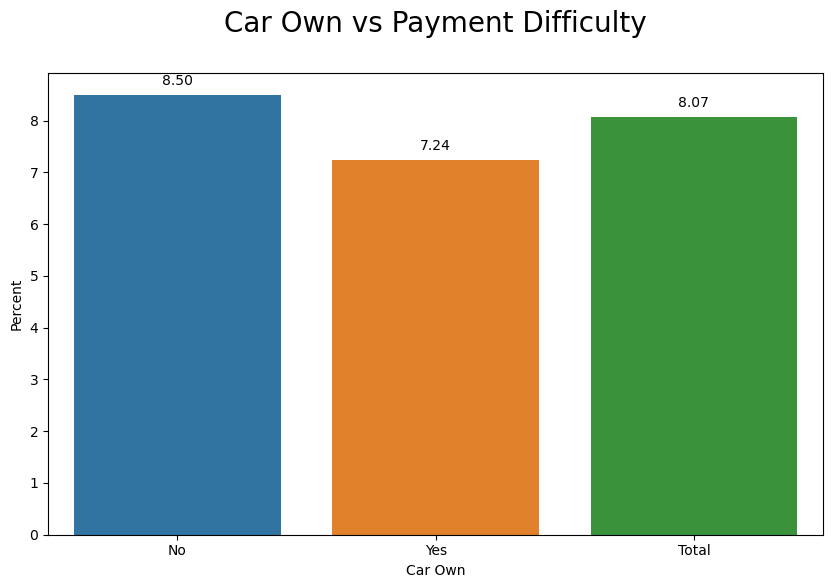

In [58]:
fig3 = plt.figure(figsize = [10,6])
ax = sns.barplot(x = 'index',
            y = 'Yes', 
            data = car_own_prop)
plt.xlabel("Car Own")
plt.ylabel("Percent")
plt.title("Car Own vs Payment Difficulty\n", fontdict={'fontsize': 20, 'fontweight' : 20, 'color' : 'Black'})
for p in ax.patches:
    ax.annotate(f'{p.get_height():0.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
fig3.show()
# fig3.savefig('car_own_tar.png', bbox_inches='tight')

In [ ]:
app_df["FLAG_OWN_REALTY"].value_counts()

In [ ]:
### frequency table using crosstab()function
 
my_crosstab = pd.crosstab(index=app_df["FLAG_OWN_REALTY"], 
                            columns=app_df["TARGET"],
                             margins=True)

#### Rename the index and columns
 
my_crosstab.columns = ["No" , "Yes" , "rowtotal"]
my_crosstab.index= ["No","Yes","Total"]
my_crosstab

## Get the row proportion
 
real_own_prop = round(my_crosstab.div(my_crosstab["rowtotal"],axis=0)*100,2)
real_own_prop

# Reset Index
real_own_prop.reset_index(level=0, inplace=True)

# Create Barplot

fig3 = plt.figure(figsize = [10,6])
ax = sns.barplot(x = 'index',
            y = 'Yes', 
            data = real_own_prop)
plt.xlabel("Realty Own")
plt.ylabel("Percent")
plt.title("Realty Own vs Payment Difficulty\n", fontdict={'fontsize': 20, 'fontweight' : 20, 'color' : 'Black'})
for p in ax.patches:
    ax.annotate(f'{p.get_height():0.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
fig3.show()
fig3.savefig('real_own_tar.png', bbox_inches='tight')

In [ ]:
app_df["AMT_CREDIT"].hist()

In [ ]:
round(app_df["AMT_CREDIT"].describe(percentiles = [.25,.5,.75,.85,.9,.95,.99]))

In [ ]:
(app_df["AMT_CREDIT"] > 1854000).sum()

In [ ]:
sns.boxplot(y = "AMT_CREDIT", data = app_df)

In [ ]:
app_df['Amt_Cred_Class'] = pd.cut(app_df['AMT_CREDIT'], [0,500000,1000000,1500000,2000000, 2500000, 3000000, 3500000, 4000000, 4500000])

In [ ]:
app_df.head()

In [ ]:
app_df.AMT_INCOME_TOTAL.skew()

In [ ]:
### frequency table using crosstab()function
 
my_crosstab = pd.crosstab(index=app_df["Amt_Cred_Class"], 
                            columns=app_df["TARGET"],
                             margins=True)

#### Rename the index and columns
 
my_crosstab.columns = ["No" , "Yes" , "rowtotal"]
my_crosstab.index= ["< 5 lakhs", "5-10 lakhs", "10-15 lakhs", "15-20 lakhs", 
                    "20-25 lakhs", "25-30 lakhs", "30-35 lakhs", "35-40 lakhs", 
                    ">=40 lakhs", "Total"]
my_crosstab

## Get the row proportion
 
amt_cred_prop = round(my_crosstab.div(my_crosstab["rowtotal"],axis=0)*100,2)


# Reset Index
amt_cred_prop.reset_index(level=0, inplace=True)

# Create Barplot

fig4 = plt.figure(figsize = [10,6])
ax = sns.barplot(x = 'index',
            y = 'Yes', 
            data = amt_cred_prop)
plt.xlabel("Amount Credit")
plt.ylabel("Percent")
plt.xticks(rotation=90)
plt.title("Amout Credit vs Payment Difficulty\n", fontdict={'fontsize': 20, 'fontweight' : 20, 'color' : 'Black'})
for p in ax.patches:
    ax.annotate(f'{p.get_height():0.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
fig4.show()
fig4.savefig('amt_cred_tar.png', bbox_inches='tight')

In [ ]:
app_df["AMT_ANNUITY"].hist()

In [ ]:
sns.boxplot(y = "AMT_ANNUITY", data = app_df)

In [ ]:
round(app_df["AMT_ANNUITY"].describe(percentiles = [.25,.5,.75,.85,.9,.95,.99]))

In [ ]:
(app_df["AMT_ANNUITY"] > 240000).sum()

In [ ]:
app_df.AMT_ANNUITY[app_df.AMT_ANNUITY > 240000] = 240000

In [ ]:
sns.boxplot(y = "AMT_ANNUITY", data = app_df)

In [ ]:
round(app_df["AMT_ANNUITY"].describe(percentiles = [.25,.5,.75,.85,.9,.95,.99]))

In [ ]:
app_df['Amt_Annuity_Class'] = pd.cut(app_df['AMT_ANNUITY'], [0,25000,50000,75000,100000, 125000, 150000, 175000, 200000, 225000])

In [ ]:
app_df.head()

In [ ]:
### frequency table using crosstab()function
 
my_crosstab = pd.crosstab(index=app_df["Amt_Annuity_Class"], 
                            columns=app_df["TARGET"],
                             margins=True)

#### Rename the index and columns
 
my_crosstab.columns = ["No" , "Yes" , "rowtotal"]
my_crosstab.index= ["< 25K", "25K-50K", "50K-75K", "75K-100K", 
                    "100K-125K", "125K-150K", "150K-175K", "175K-200K", 
                    ">= 200K", "Total"]
my_crosstab

## Get the row proportion
 
amt_cred_prop = round(my_crosstab.div(my_crosstab["rowtotal"],axis=0)*100,2)


# Reset Index
amt_cred_prop.reset_index(level=0, inplace=True)

# Create Barplot

fig4 = plt.figure(figsize = [10,6])
ax = sns.barplot(x = 'index',
            y = 'Yes', 
            data = amt_cred_prop)
plt.xlabel("Amount Annuity")
plt.ylabel("Percent")
plt.xticks(rotation=90)
plt.title("Amout Annuity vs Payment Difficulty\n", fontdict={'fontsize': 20, 'fontweight' : 20, 'color' : 'Black'})
for p in ax.patches:
    ax.annotate(f'{p.get_height():0.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
fig4.show()
fig4.savefig('amt_annuity_tar.png', bbox_inches='tight')

In [ ]:
app_df["AMT_GOODS_PRICE"].hist()

In [ ]:
sns.boxplot(y = "AMT_GOODS_PRICE", data = app_df)

In [ ]:
round(app_df["AMT_GOODS_PRICE"].describe(percentiles = [.25,.5,.75,.85,.9,.95,.99]))

In [ ]:
app_df['Amt_Goods_Price_Class'] = pd.cut(app_df['AMT_GOODS_PRICE'], [0,500000,1000000,1500000,2000000, 2500000, 3000000, 3500000, 4000000, 4500000])

In [ ]:
app_df.head()

In [ ]:
### frequency table using crosstab()function
 
my_crosstab = pd.crosstab(index=app_df["Amt_Goods_Price_Class"], 
                            columns=app_df["TARGET"],
                             margins=True)

#### Rename the index and columns
 
my_crosstab.columns = ["No" , "Yes" , "rowtotal"]
my_crosstab.index= ["< 5Lakhs", "5-10Lakhs", "10-15Lakhs", "15-20Lakhs", 
                    "20-25Lakhs", "25-30Lakhs", "30-35Lakhs", "35-40Lakhs", 
                    ">= 40Lakhs", "Total"]
my_crosstab

## Get the row proportion
 
amt_cred_prop = round(my_crosstab.div(my_crosstab["rowtotal"],axis=0)*100,2)


# Reset Index
amt_cred_prop.reset_index(level=0, inplace=True)

# Create Barplot

fig4 = plt.figure(figsize = [10,6])
ax = sns.barplot(x = 'index',
            y = 'Yes', 
            data = amt_cred_prop)
plt.xlabel("Amount Goods Price")
plt.ylabel("Percent")
plt.xticks(rotation=90)
plt.title("Amout Goods Price vs Payment Difficulty\n", fontdict={'fontsize': 20, 'fontweight' : 20, 'color' : 'Black'})
for p in ax.patches:
    ax.annotate(f'{p.get_height():0.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
fig4.show()
fig4.savefig('amt_goods_price_tar.png', bbox_inches='tight')

In [ ]:
app_df["NAME_TYPE_SUITE"].value_counts()

In [ ]:
### frequency table using crosstab()function
 
my_crosstab = pd.crosstab(index=app_df["NAME_TYPE_SUITE"], 
                            columns=app_df["TARGET"],
                             margins=True)   # Include row and column totals

my_crosstab

In [ ]:
#### Rename the index and columns
 
my_crosstab.columns = ["No" , "Yes" , "rowtotal"]
my_crosstab.index= ["Children","Family","Group of people", "Other_A", "Other_B",
                    "Spouse/Partner", "Unaccompanied", "Total"]
my_crosstab

In [ ]:
## Get the row proportion
 
suit_prop = round(my_crosstab.div(my_crosstab["rowtotal"],axis=0)*100,2)
suit_prop

In [ ]:
suit_prop.reset_index(level=0, inplace=True)

In [ ]:
# Create Barplot

fig3 = plt.figure(figsize = [10,6])
ax = sns.barplot(x = 'index',
            y = 'Yes', 
            data = suit_prop)
plt.xlabel("Suit Type")
plt.ylabel("Percent")
plt.xticks(rotation=30)
plt.title("Type of Suite vs Payment Difficulty\n", fontdict={'fontsize': 20, 'fontweight' : 20, 'color' : 'Black'})
for p in ax.patches:
    ax.annotate(f'{p.get_height():0.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
fig3.show()
fig3.savefig('suit_tar.png', bbox_inches='tight')

In [ ]:
app_df["NAME_INCOME_TYPE"].value_counts()

In [ ]:
### frequency table using crosstab()function
 
my_crosstab = pd.crosstab(index=app_df["NAME_INCOME_TYPE"], 
                            columns=app_df["TARGET"],
                             margins=True)   # Include row and column totals

my_crosstab

In [ ]:
#### Rename the index and columns
 
my_crosstab.columns = ["No" , "Yes" , "rowtotal"]
my_crosstab.index= ["Businessman","Commercial associate","Maternity leave", "Pensioner", "State servant",
                    "Student", "Unemployed","Working", "Total"]
my_crosstab

In [ ]:
## Get the row proportion
 
Income_Type_prop = round(my_crosstab.div(my_crosstab["rowtotal"],axis=0)*100,2)
Income_Type_prop

In [ ]:
Income_Type_prop.reset_index(level=0, inplace=True)

In [ ]:
# Create Barplot

fig3 = plt.figure(figsize = [10,6])
ax = sns.barplot(x = 'index',
            y = 'Yes', 
            data = Income_Type_prop)
plt.xlabel("Income Type")
plt.ylabel("Percent")
plt.xticks(rotation=30)
plt.title("Income Type vs Payment Difficulty\n", fontdict={'fontsize': 20, 'fontweight' : 20, 'color' : 'Black'})
for p in ax.patches:
    ax.annotate(f'{p.get_height():0.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
fig3.show()
fig3.savefig('income_type_tar.png', bbox_inches='tight')

In [ ]:
app_df["NAME_EDUCATION_TYPE"].value_counts()

In [ ]:
### frequency table using crosstab()function
 
my_crosstab = pd.crosstab(index=app_df["NAME_EDUCATION_TYPE"], 
                            columns=app_df["TARGET"],
                             margins=True)   # Include row and column totals

my_crosstab

In [ ]:

#### Rename the index and columns
 
my_crosstab.columns = ["No" , "Yes" , "rowtotal"]
my_crosstab.index= ["Academic Degree","Higher Education","Incomplete Higher", "Lower Secondary", "Secondary /Secondary Special",
                     "Total"]
my_crosstab

In [ ]:
## Get the row proportion
 
Edu_Type_prop = round(my_crosstab.div(my_crosstab["rowtotal"],axis=0)*100,2)
Edu_Type_prop

In [ ]:
Edu_Type_prop.reset_index(level=0, inplace=True)

In [ ]:
# Create Barplot

fig3 = plt.figure(figsize = [10,6])
ax = sns.barplot(x = 'index',
            y = 'Yes', 
            data = Edu_Type_prop)
plt.xlabel("Education Type")
plt.ylabel("Percent")
plt.xticks(rotation=30)
plt.title("Education Type vs Payment Difficulty\n", fontdict={'fontsize': 20, 'fontweight' : 20, 'color' : 'Black'})
for p in ax.patches:
    ax.annotate(f'{p.get_height():0.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
fig3.show()
fig3.savefig('edu_type_tar.png', bbox_inches='tight')

In [ ]:
app_df["NAME_FAMILY_STATUS"].value_counts()

In [ ]:
### frequency table using crosstab()function
 
my_crosstab = pd.crosstab(index=app_df["NAME_FAMILY_STATUS"], 
                            columns=app_df["TARGET"],
                             margins=True)   # Include row and column totals

my_crosstab

In [ ]:

#### Rename the index and columns
 
my_crosstab.columns = ["No" , "Yes" , "rowtotal"]
my_crosstab.index= ["Civil Marriage","Married","Separated", "Single/Unmarried", "Unknown",
                     "Widow", "Total"]
my_crosstab

In [ ]:
## Get the row proportion
 
fam_Type_prop = round(my_crosstab.div(my_crosstab["rowtotal"],axis=0)*100,2)
fam_Type_prop

In [ ]:
fam_Type_prop.reset_index(level=0, inplace=True)

In [ ]:
# Create Barplot

fig3 = plt.figure(figsize = [10,6])
ax = sns.barplot(x = 'index',
            y = 'Yes', 
            data = fam_Type_prop)
plt.xlabel("Family Type")
plt.ylabel("Percent")
plt.xticks(rotation=30)
plt.title("Family Type vs Payment Difficulty\n", fontdict={'fontsize': 20, 'fontweight' : 20, 'color' : 'Black'})
for p in ax.patches:
    ax.annotate(f'{p.get_height():0.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
fig3.show()
fig3.savefig('fam_type_tar.png', bbox_inches='tight')

In [ ]:
app_df["NAME_HOUSING_TYPE"].value_counts()

In [ ]:
### frequency table using crosstab()function
 
my_crosstab = pd.crosstab(index=app_df["NAME_HOUSING_TYPE"], 
                            columns=app_df["TARGET"],
                             margins=True)   # Include row and column totals

my_crosstab

In [ ]:
#### Rename the index and columns
 
my_crosstab.columns = ["No" , "Yes" , "rowtotal"]
my_crosstab.index= ["Co-op Apartment","House/Aapartment","Municipal Apartment", "Office Apartment", "Rented Apartment",
                     "With Parents", "Total"]
my_crosstab

In [ ]:
## Get the row proportion
 
hou_Type_prop = round(my_crosstab.div(my_crosstab["rowtotal"],axis=0)*100,2)
hou_Type_prop

In [ ]:
hou_Type_prop.reset_index(level=0, inplace=True)

In [ ]:
# Create Barplot

fig3 = plt.figure(figsize = [10,6])
ax = sns.barplot(x = 'index',
            y = 'Yes', 
            data = hou_Type_prop)
plt.xlabel("House Type")
plt.ylabel("Percent")
plt.xticks(rotation=30)
plt.title("House Type vs Payment Difficulty\n", fontdict={'fontsize': 20, 'fontweight' : 20, 'color' : 'Black'})
for p in ax.patches:
    ax.annotate(f'{p.get_height():0.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
fig3.show()
fig3.savefig('hou_type_tar.png', bbox_inches='tight')